Code for calculating the barotropic and overturning streamfunctions for both ANHA4 and ANHA12. This assumes that for the barotropic streamfunction, you start from the north and work your way down

In [1]:
import os
os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/"
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4 as nc
from netCDF4 import Dataset

import datetime
import cftime
import time

import gsw

In [2]:
def get_files(path, mask_path):
    files = []
    for x in ['_gridU.nc','_gridV.nc','_gridT.nc']:
       files.append(xr.open_mfdataset(path + x))
    mask = xr.open_mfdataset(mask_path)
    return files, mask

In [95]:
def barotropic_sf(file, mask, inds):
    ds_u = files[0].rename({'depthu': 'depth'})
    ds_v = files[1].rename({'depthv': 'depth'})
    
    i_face = (ds_u['e3u'][0, :, inds[0]:inds[1], inds[2]:inds[3]] * mask['e1u'][0, inds[0]:inds[1], inds[2]:inds[3]]).compute() # area of vertical cell face along i-axis, for v 
    j_face = (ds_v['e3v'][0, :, inds[0]:inds[1], inds[2]:inds[3]] * mask['e2v'][0, inds[0]:inds[1], inds[2]:inds[3]]).compute() # area of vertical cell face alone j-axis horizontal, for u

    print(i_face.shape)
    print(j_face.shape)
    #now we calculate the volume flux, salinity flux, heat flux, and freshwater flux

    v_trans = (i_face * ds_v['vomecrty'][0, :, inds[0]:inds[1], inds[2]:inds[3]]).compute() # meridional transport
    u_trans = (j_face * ds_u['vozocrtx'][0, :, inds[0]:inds[1], inds[2]:inds[3]]).compute() # zonal transport

    print(u_trans.shape)
    print(v_trans.shape)

    tot_trans = v_trans + u_trans

    print(tot_trans.shape)

    depth_int = np.nansum(tot_trans, axis = 0)

    btsf = np.nancumsum(depth_int, axis = 1)

    print(btsf.shape)

    return btsf
    

In [96]:
def overturning_plotter():
    return

In [229]:
u = xr.open_dataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25_gridU.nc").rename({'depthu': 'depth'})
v = xr.open_dataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25_gridV.nc").rename({'depthv': 'depth'})
mask = xr.open_dataset('/mnt/storage4/grace/grace/data/model_masks/ANHA4_mesh_mask.nc')
inds = [250, 450, 150, 375]

u_t = u['vozocrtx'][0,:,250:450, 150:375]
u_z = u['e3u'][0, :, 250:450, 150:375]
u_y = mask['e2u'][0, 250:450, 150:375]

u_t1 = u['vozocrtx'][0,:,:,:]
u_z1 = u['e3u'][0, :, :,:]
u_y1 = mask['e2u'][0, :,:]

In [228]:
v_t = v['vomecrty'][0,:,250:450, 150:375]
v_z = v['e3v'][0, :, 250:450, 150:375]
v_x = mask['e1v'][0, 250:450, 150:375]

v_t1 = v['vomecrty'][0,:,:,:]
v_z1 = v['e3v'][0, :, :,:]
v_x1 = mask['e1v'][0, :,:]

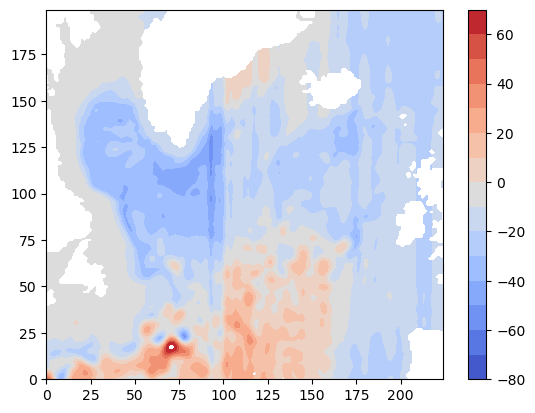

In [230]:
btsf1 = np.cumsum(np.sum(-u_t1 * u_z1, axis = 0) * u_y1, axis = 0)
plt.contourf(np.where(mask['umask'][0,0,250:450,150:375], btsf1[250:450,150:375] / 1e6, np.nan), np.arange(-80, 80, 10), cmap = 'coolwarm')
plt.colorbar()

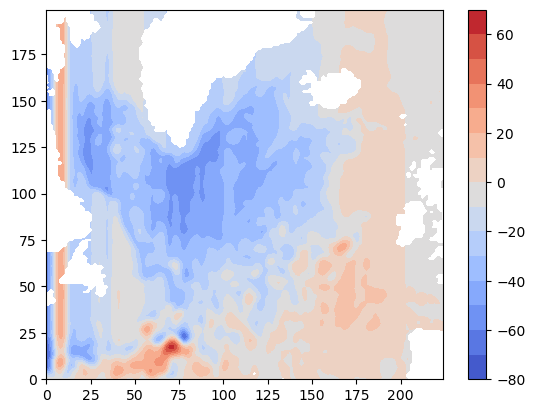

In [224]:
btsf1 = np.cumsum(np.sum(-u_t * u_z, axis = 0) * u_y, axis = 0)
plt.contourf(np.where(mask['umask'][0,0,250:450,150:375], btsf1 / 1e6, np.nan), np.arange(-80, 80, 10), cmap = 'coolwarm')
plt.colorbar()

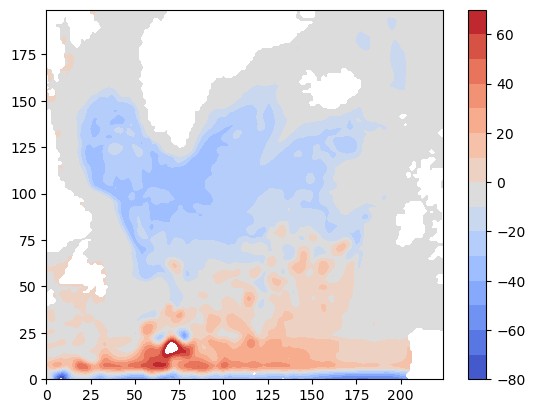

In [227]:
btsf1 = np.cumsum(np.sum(v_t * v_z, axis = 0) * v_x, axis = 1)
plt.contourf(np.where(mask['umask'][0,0,250:450,150:375], btsf1 / 1e6, np.nan), np.arange(-80, 80, 10), cmap = 'coolwarm')
plt.colorbar()

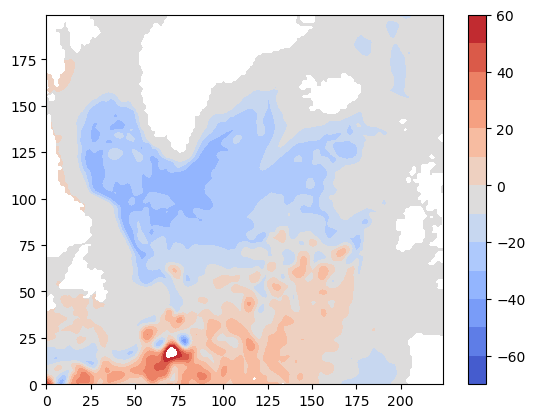

In [236]:
btsf1 = np.cumsum(np.sum(v_t1 * v_z1, axis = 0) * v_x1, axis = 1)
plt.contourf(np.where(mask['umask'][0,0,250:450,150:375], btsf1[250:450,150:375] / 1e6, np.nan), np.arange(-70, 70, 10), cmap = 'coolwarm')
plt.colorbar()

In [2]:
v = xr.open_dataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2018m05d25_gridV.nc").rename({'depthv': 'depth'})
mask = xr.open_dataset('/mnt/storage4/grace/grace/data/model_masks/ANHA12_mask.nc')
hgr = xr.open_dataset('/mnt/storage4/grace/grace/data/model_masks/ANHA12_mesh_hgr.nc')
zgr = xr.open_dataset('/mnt/storage4/grace/grace/data/model_masks/ANHA12_mesh_zgr.nc')

v_t12 = v['vomecrty'][0,:,:,:]
v_z12 = zgr['e3v'][0, :, :,:]
v_x12 = hgr['e1v'][0, :,:]

In [ ]:
n = (v_t12 * v_z12).compute()
m = np.sum(n, axis = 0)
print('done m')
o = m * v_x12
print('done o')
btsf12 = np.cumsum(o, axis = 1)
print('done p')

In [ ]:
plt.contourf(np.where(mask['vmask'][0,0,750:1350,450:1125], btsf1[750:1350,450:1125] / 1e6, np.nan), np.arange(-70, 70, 10), cmap = 'coolwarm')
plt.colorbar()

In [85]:
if __name__ == "__main__":
    inds = [250, 450, 150, 375]
    files, mask = get_files("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2018m05d25", '/mnt/storage4/grace/grace/data/model_masks/ANHA4_mesh_mask.nc')
    btsf = barotropic_sf(files, mask, inds)
    #barotropic_plotter(btsf, inds)

(50, 200, 225)
(50, 200, 225)
(50, 200, 225)
(50, 200, 225)
(50, 200, 225)
(50, 200, 225)
